# How the training decoys are chosen

The ranking loss of `train_MLP_negatives.py` asks the predicted fingerprint to score the true structure above some
**decoys**: structures the model must not confuse it with. At retrieval time the competition is every pool structure of
the same mass, so the decoys are drawn from there.

For one training molecule, we follow:
1. **Where decoys come from**: its mass window (±10 ppm) in the candidate pool (train + PubChem, `external/pool/`).
   What is in it: isomers, other formulas, and "twins" (same fingerprint as the molecule) that cannot be decoys.
2. **Fixed decoys** (`library/negatives.npz`, `build_negatives.py`, used by `mlp_negatives`): 32 drawn once per molecule.
3. **Fresh decoys** (`library/negative_bank.npz`, `build_negative_bank.py`, used by `mlp_resampled` and `mlp_combined`):
   32 new ones at every batch, from a random 4.5% sample of the pool.
4. **How hard they are**: Tanimoto similarity between the molecule and its decoys.
5. The window sizes over all molecules.

In [1]:
import sys

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
from rdkit import Chem
from rdkit.Chem import Draw, rdMolDescriptors

from build_negative_bank import BANK_FRACTION
from build_negatives import N_DRAWN, N_NEGATIVES
from build_spectrum_arrays import TRAIN_PATH
from morgan_generator import N_BITS, fingerprint
from rank_candidates import PPM_TOLERANCE, mass_windows
from train_MLP import LIBRARY_DIR, SEED, split_spectra_by_molecule

sys.path.insert(0, "pubchem_pool")
from build_pool import POOL_DIR

EXAMPLE_SEED = 3  # change it to look at another molecule

In [2]:
def molecular_formula(smiles: str) -> str | None:
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    return rdMolDescriptors.CalcMolFormula(mol)


def tanimoto(bits: np.ndarray, other_bits: np.ndarray) -> np.ndarray:
    """Tanimoto between one 0/1 fingerprint (N_BITS,) and each row of other_bits (n, N_BITS)."""
    intersection = other_bits @ bits
    union = bits.sum() + other_bits.sum(axis=1) - intersection
    return intersection / union

## 0. A training molecule

Decoys matter for the molecules the MLP trains on. We take the training split of `train_MLP.py` (same seed) and pick one.

263,414 training molecules
example: XYQOTKLECWUHSD  C16H21N3O4  exact mass 319.1532 Da
COCc1ccoc1C(=O)NC1CC(Cn2cccn2)CC1O  (55 bits on)


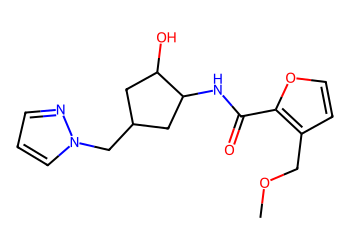

In [3]:
spectrum_info = pl.scan_parquet(TRAIN_PATH).select("ingest_lib").collect()
fp_index = np.load(LIBRARY_DIR / "spectrum_arrays.npz")["fp_index"]
rng = np.random.default_rng(SEED)
train_indices, _ = split_spectra_by_molecule(fp_index, spectrum_info["ingest_lib"], rng)
trained_fp_index = np.unique(fp_index[train_indices])

molecules = pl.read_parquet(LIBRARY_DIR / "molecules.parquet")
library_fingerprints = np.load(LIBRARY_DIR / "morgan_fingerprints.npy")

example_fp_index = int(np.random.default_rng(EXAMPLE_SEED).choice(trained_fp_index))
example = molecules.filter(pl.col("fp_index") == example_fp_index).row(0, named=True)
example_bits = np.unpackbits(library_fingerprints[example_fp_index], count=N_BITS).astype(np.float32)
example_formula = molecular_formula(example["normalized_smiles"])

print(f"{len(trained_fp_index):,} training molecules")
print(f"example: {example['inchikey14']}  {example_formula}  exact mass {example['exact_mass']:.4f} Da")
print(f"{example['normalized_smiles']}  ({int(example_bits.sum())} bits on)")
Draw.MolToImage(Chem.MolFromSmiles(example["normalized_smiles"]), size=(350, 250))

## 1. Where decoys come from: the mass window in the pool

Every pool structure within ±10 ppm of the molecule's exact mass. At retrieval time, these are its competitors.

In [4]:
mass = example["exact_mass"]
tolerance = mass * PPM_TOLERANCE * 1e-6
window = (
    pl.scan_parquet(POOL_DIR / "pool_*.parquet")
    .filter(pl.col("mass").is_between(mass - tolerance, mass + tolerance))
    .select("key", "smiles", "mass", "source")
    .collect()
)
window = window.with_columns(pl.Series("formula", [molecular_formula(smiles) for smiles in window["smiles"]]))

print(f"±{PPM_TOLERANCE:g} ppm = ±{tolerance:.4f} Da: {window.height:,} pool structures")
print(window["source"].value_counts().sort("count", descending=True))
window["formula"].value_counts().sort("count", descending=True).head(8)

±10 ppm = ±0.0032 Da: 8,271 pool structures
shape: (2, 2)
┌─────────┬───────┐
│ source  ┆ count │
│ ---     ┆ ---   │
│ str     ┆ u32   │
╞═════════╪═══════╡
│ pubchem ┆ 8157  │
│ train   ┆ 114   │
└─────────┴───────┘


formula,count
str,u32
"""C16H21N3O4""",5758
"""C17H17N7""",754
"""C14H20F3N3O2""",552
"""C16H22ClN5""",442
"""C15H30BrNO""",178
"""C17H22FN3S""",173
"""C19H20F3N""",131
"""C16H21F4NO""",64


Within 10 ppm, almost every structure has the **same formula** as the molecule: the decoys are mostly isomers, the hard case
for a fingerprint (same atoms, different connectivity). A few other formulas fall in the window by mass coincidence.

isomers (formula C16H21N3O4): 69.6% of the window


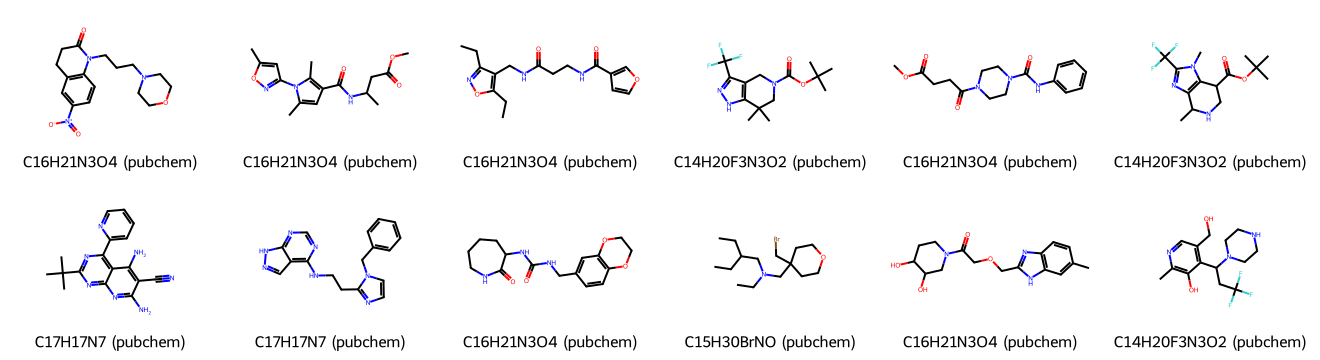

In [5]:
is_isomer = (window["formula"] == example_formula).to_numpy()
print(f"isomers (formula {example_formula}): {is_isomer.mean():.1%} of the window")

shown = window.sample(12, seed=0)
Draw.MolsToGridImage(
    [Chem.MolFromSmiles(smiles) for smiles in shown["smiles"]],
    molsPerRow=6, subImgSize=(220, 180),
    legends=[f"{formula} ({source})" for formula, source in shown.select("formula", "source").iter_rows()],
)

### Twins: structures that cannot be decoys

Some window structures have exactly the molecule's fingerprint: the molecule itself, its stereoisomers (the Morgan
fingerprint ignores stereo), and rare hash collisions. The loss cannot separate them from the truth, so both decoy
schemes drop them: `build_negatives.py` skips them, and `ResampledBatcher.draw_negatives` masks them.

In [6]:
window_bits = []
window_rows = []
for row_number, smiles in enumerate(window["smiles"]):
    bits = fingerprint(smiles)
    if bits is not None:
        window_bits.append(bits)
        window_rows.append(row_number)
window_bits = np.stack(window_bits).astype(np.float32)
window_parsed = window[window_rows]

is_twin = (window_bits == example_bits).all(axis=1)
print(f"{len(window_rows):,} structures parsed by RDKit, {is_twin.sum()} twins of the molecule:")
window_parsed.filter(pl.Series(is_twin)).select("key", "source", "smiles")

8,271 structures parsed by RDKit, 1 twins of the molecule:


key,source,smiles
str,str,str
"""XYQOTKLECWUHSD""","""train""","""COCc1ccoc1C(=O)NC1CC(Cn2cccn2)…"


## 2. Fixed decoys (`negatives.npz`, used by `mlp_negatives`)

Built once by `build_negatives.py`: for each molecule, draw 48 random structures of its pool window (molecules the MLP never
trains on removed), fingerprint them, keep the first 32 that parse and are not twins. The model sees **the same 32 at
every epoch**, so it can learn those 32 by heart instead of learning to separate look-alikes in general.

In [7]:
negatives = np.load(LIBRARY_DIR / "negatives.npz")  # lazy: only the arrays read below are loaded
n_negatives = negatives["n_negatives"]
pool_window_size = negatives["window_size"]
print(f"{N_DRAWN} drawn, at most {N_NEGATIVES} kept")
print(f"example: {n_negatives[example_fp_index]} fixed decoys, pool window of {pool_window_size[example_fp_index]:,} at build time")

48 drawn, at most 32 kept
example: 32 fixed decoys, pool window of 8,266 at build time


## 3. Fresh decoys (`negative_bank.npz`, used by `mlp_resampled` and `mlp_combined`)

Fingerprinting pool structures during training would be far too slow, so `build_negative_bank.py` fingerprinted a random
4.5% of the pool once (held-out molecules removed), sorted by mass: the **bank**. At every batch,
`ResampledBatcher.draw_negatives` draws 32 random rows of the molecule's window in the bank (with replacement), and masks
the twins and the empty slots of small windows.

In [8]:
bank = np.load(LIBRARY_DIR / "negative_bank.npz")
bank_masses = bank["masses"]
bank_fingerprints = bank["fingerprints"]  # (n_bank, N_BITS / 8) bit-packed, ~1 GB
starts, ends = mass_windows(bank_masses, np.array([mass]))
bank_start = int(starts[0])
bank_window_size = int(ends[0] - starts[0])

print(f"bank: {len(bank_masses):,} structures ({BANK_FRACTION:.1%} of the pool)")
print(f"example: {bank_window_size} bank structures in its window, vs {window.height:,} in the pool")

bank: 4,047,703 structures (4.5% of the pool)
example: 393 bank structures in its window, vs 8,271 in the pool


In [9]:
draw_rng = np.random.default_rng(0)


def draw_decoy_rows() -> np.ndarray:
    """Bank rows of one draw, as ResampledBatcher.draw_negatives does it for one spectrum."""
    offsets = np.floor(draw_rng.random(N_NEGATIVES) * bank_window_size).astype(np.int64)
    return bank_start + offsets


first_draw = draw_decoy_rows()
second_draw = draw_decoy_rows()
print(f"draw 1: {len(np.unique(first_draw))} distinct structures among {N_NEGATIVES} (drawn with replacement)")
print(f"draw 2 (next time this spectrum is in a batch): {len(np.intersect1d(first_draw, second_draw))} in common with draw 1")

bank_window_bits = np.unpackbits(bank_fingerprints[bank_start:bank_start + bank_window_size], axis=1, count=N_BITS).astype(np.float32)
bank_is_twin = (bank_window_bits == example_bits).all(axis=1)
print(f"twins in the bank window (masked if drawn): {bank_is_twin.sum()}")

draw 1: 31 distinct structures among 32 (drawn with replacement)
draw 2 (next time this spectrum is in a batch): 1 in common with draw 1
twins in the bank window (masked if drawn): 0


## 4. How hard are the decoys?

The Tanimoto similarity between the molecule's fingerprint and a decoy's says how close a look-alike it is. Random draws
from the window are mostly far from the molecule; the few close ones are the decoys that teach the model something.

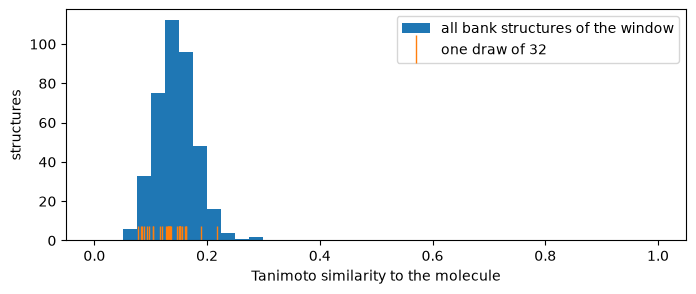

bank window: median similarity 0.14, above 0.5: 0.0%
one draw: median 0.13, max 0.22


In [10]:
bank_similarity = tanimoto(example_bits, bank_window_bits[~bank_is_twin])
drawn_similarity = tanimoto(example_bits, bank_window_bits[first_draw - bank_start])

fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(bank_similarity, bins=40, range=(0, 1), color="tab:blue", label="all bank structures of the window")
ax.plot(drawn_similarity, np.zeros_like(drawn_similarity), "|", color="tab:orange", markersize=20, label="one draw of 32")
ax.set_xlabel("Tanimoto similarity to the molecule")
ax.set_ylabel("structures")
ax.legend()
plt.show()

print(f"bank window: median similarity {np.median(bank_similarity):.2f}, above 0.5: {np.mean(bank_similarity > 0.5):.1%}")
print(f"one draw: median {np.median(drawn_similarity):.2f}, max {drawn_similarity.max():.2f}")

The hardest decoys of the full pool window: the structures closest to the molecule that are not twins. These are the ones
retrieval has to beat, and that random draws rarely pick.

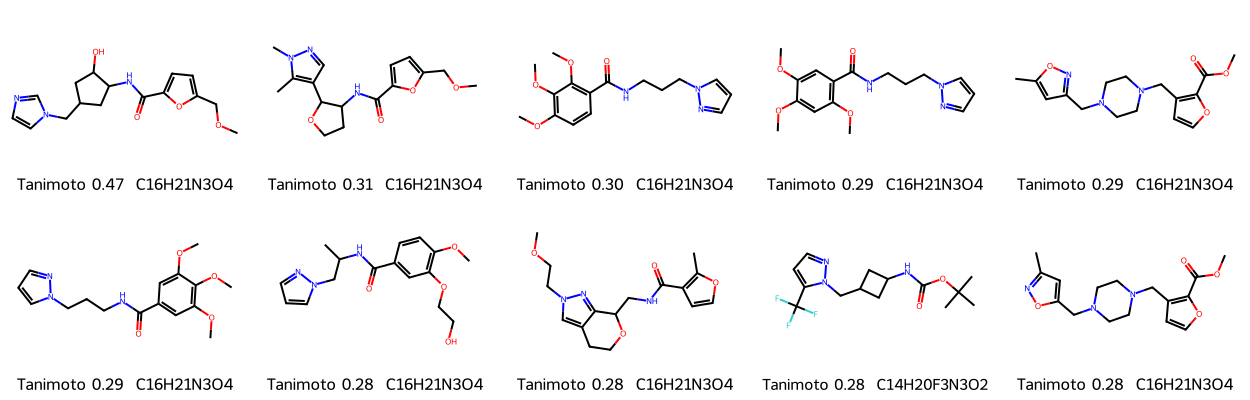

In [11]:
pool_similarity = tanimoto(example_bits, window_bits)
pool_similarity[is_twin] = -1  # twins are not decoys
hardest = np.argsort(pool_similarity)[::-1][:10].tolist()

Draw.MolsToGridImage(
    [Chem.MolFromSmiles(window_parsed["smiles"][i]) for i in hardest],
    molsPerRow=5, subImgSize=(250, 200),
    legends=[f"Tanimoto {pool_similarity[i]:.2f}  {window_parsed['formula'][i]}" for i in hardest],
)

## 5. Over all molecules: how many decoys are there?

The pool window sizes were saved by `build_negatives.py`; the bank windows are the same windows in the 4.5% sample.
A bank window below 32 structures gives fewer than 32 real decoys (some drawn twice), an empty one gives none.

training molecules: pool window median 9,291, bank window median 419
bank window below 32: 6.9%, empty: 0.8%
fixed decoys: fewer than 32 for 1.1%, none for 0.3%


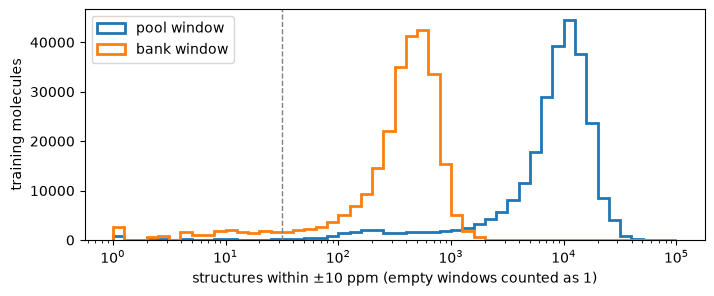

In [12]:
bank_starts, bank_ends = mass_windows(bank_masses, molecules["exact_mass"].to_numpy())
bank_window_sizes = bank_ends - bank_starts
trained = np.zeros(molecules.height, dtype=bool)
trained[trained_fp_index] = True

print(f"training molecules: pool window median {np.median(pool_window_size[trained]):,.0f}, "
      f"bank window median {np.median(bank_window_sizes[trained]):,.0f}")
print(f"bank window below {N_NEGATIVES}: {np.mean(bank_window_sizes[trained] < N_NEGATIVES):.1%}, "
      f"empty: {np.mean(bank_window_sizes[trained] == 0):.1%}")
print(f"fixed decoys: fewer than {N_NEGATIVES} for {np.mean(n_negatives[trained] < N_NEGATIVES):.1%}, "
      f"none for {np.mean(n_negatives[trained] == 0):.1%}")

bins = np.logspace(0, 5, 51)
fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(np.maximum(pool_window_size[trained], 1), bins=bins, histtype="step", linewidth=2, color="tab:blue", label="pool window")
ax.hist(np.maximum(bank_window_sizes[trained], 1), bins=bins, histtype="step", linewidth=2, color="tab:orange", label="bank window")
ax.axvline(N_NEGATIVES, color="gray", linestyle="--", linewidth=1)
ax.set_xscale("log")
ax.set_xlabel("structures within ±10 ppm (empty windows counted as 1)")
ax.set_ylabel("training molecules")
ax.legend()
plt.show()

## What to take from this

- The decoys are the right population: same mass, mostly isomers, the structures retrieval actually has to beat.
- Fresh decoys avoid memorising a fixed set, but they are **random**: most are easy (low Tanimoto). The informative ones,
  the close look-alikes, are rare in a draw of 32.
- A natural next step is **hard negatives**: draw the decoys among the window structures the current model scores
  highest (or the ones most similar to the truth), instead of uniformly.